# Análisis Descriptivo

Esta sección presenta el análisis descriptivo de variables centrales del fenómeno, incluyendo caracterización univariada, evaluación de normalidad, ajuste de distribuciones y revisión de valores atípicos.

In [10]:
import pandas as pd
import prepare_file

prepare_file.generate_prepared_file()

Preparing data file (this can take a few minutes)...
File created: ../Clean_NPFC-TEST_Database_V2.csv (28.7418s)


In [11]:
df = pd.read_csv('../../Clean_NPFC-TEST_Database_V2.csv')

## Caracterización univariada

Se realiza una caracterización univariada de las variables:
- Selfreport_valence
- Selfreport_arousal
- Selfreport_focus
- resmasknet_max_emotion_value

Incluye:
- Completitud de datos (faltantes)
- Estadísticos descriptivos por variable numérica
- Asimetría y curtosis
- Detección de outliers por criterio IQR
- Distribuciones y frecuencias (gráficos univariados)

Completitud de datos por variable:


,missing_n,missing_pct
Selfreport_valence,0,0.0
Selfreport_arousal,0,0.0
Selfreport_focus,0,0.0
resmasknet_max_emotion_value,0,0.0


Resumen univariado de variables numericas:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,outliers_iqr_n,outliers_iqr_pct
Selfreport_valence,22105.0,3.218276,1.529890,0.0,2.0,4.0,4.0,5.0,-0.893636,-0.211270,0,0.00
Selfreport_arousal,22105.0,3.383443,1.599402,0.0,3.0,4.0,4.0,5.0,-1.075861,-0.034364,3818,17.27
Selfreport_focus,22105.0,3.071839,1.606795,0.0,2.0,3.0,4.0,5.0,-0.642714,-0.643218,0,0.00


Frecuencias de Selfreport_valence:


...

,count,pct
Selfreport_arousal,,
0,2683,12.14
1,1135,5.13
2,868,3.93
3,3044,13.77
4,9087,41.11
5,5288,23.92


Frecuencias de Selfreport_focus:


,count,pct
Selfreport_focus,,
0,2897,13.11
1,985,4.46
2,2922,13.22
3,4668,21.12
4,6095,27.57
5,4538,20.53


Resumen de resmasknet_max_emotion_value (alta cardinalidad):


,count,mean,std,min,25%,50%,75%,max
resmasknet_max_emotion_value,22105.0,0.685447,0.164135,0.228641,0.552432,0.681536,0.821552,0.998876


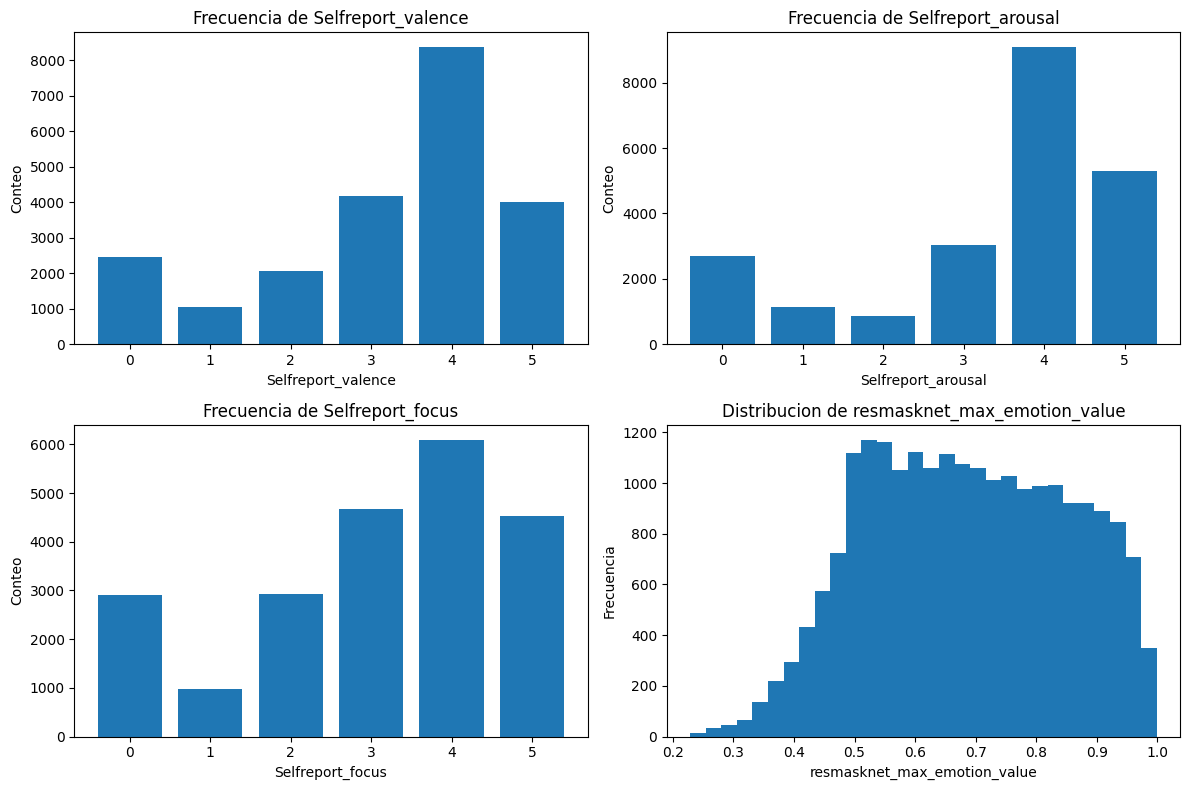

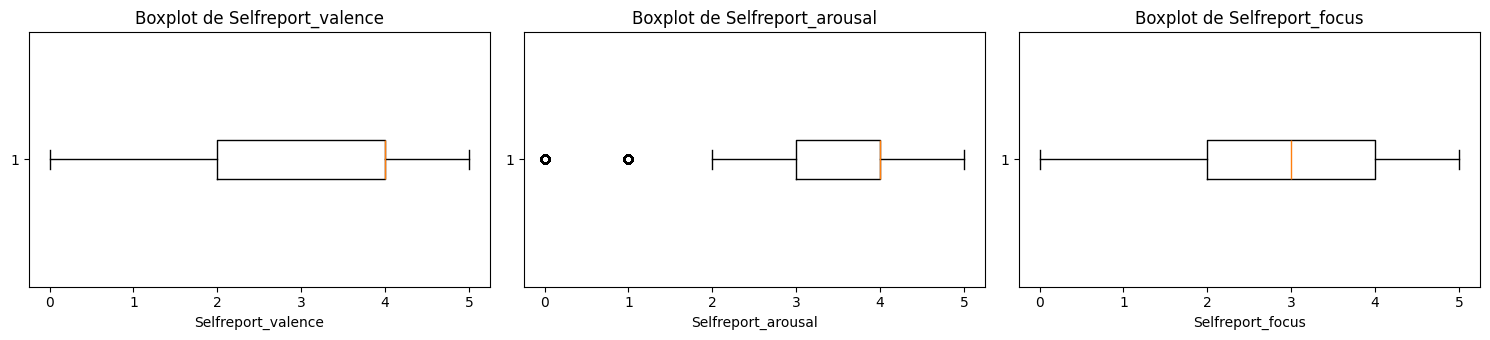

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Variables para caracterización univariada
num_vars = ["Selfreport_valence", "Selfreport_arousal", "Selfreport_focus"]
cat_vars = ["resmasknet_max_emotion_value"]
all_vars = num_vars + cat_vars

missing_cols = [col for col in all_vars if col not in df.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas en df: {missing_cols}")

analysis_df = df[all_vars].copy()

# 1) Completitud de datos
missing_table = pd.DataFrame({
    "missing_n": analysis_df.isna().sum(),
    "missing_pct": (analysis_df.isna().mean() * 100).round(2),
})
print("Completitud de datos por variable:")
display(missing_table)

# 2) Estadísticos univariados numéricos
num_summary = analysis_df[num_vars].describe().T
num_summary["skewness"] = analysis_df[num_vars].skew()
num_summary["kurtosis"] = analysis_df[num_vars].kurtosis()

# Outliers por IQR
q1 = analysis_df[num_vars].quantile(0.25)
q3 = analysis_df[num_vars].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_mask = (analysis_df[num_vars] < lower) | (analysis_df[num_vars] > upper)
outlier_count = outlier_mask.sum()

num_summary["outliers_iqr_n"] = outlier_count
num_summary["outliers_iqr_pct"] = (
    outlier_count / analysis_df[num_vars].notna().sum() * 100
).round(2)

print("Resumen univariado de variables numericas:")
display(num_summary)

# 3) Distribuciones de variables ordinales/categoricas
valence_counts = analysis_df["Selfreport_valence"].value_counts(dropna=False).sort_index()
arousal_counts = analysis_df["Selfreport_arousal"].value_counts(dropna=False).sort_index()
focus_counts = analysis_df["Selfreport_focus"].value_counts(dropna=False).sort_index()
target_col = cat_vars[0]
target_non_null = analysis_df[target_col].dropna()
target_unique = target_non_null.nunique()

print("Frecuencias de Selfreport_valence:")
display(pd.DataFrame({"count": valence_counts, "pct": (valence_counts / len(analysis_df) * 100).round(2)}))

print("Frecuencias de Selfreport_arousal:")
display(pd.DataFrame({"count": arousal_counts, "pct": (arousal_counts / len(analysis_df) * 100).round(2)}))

print("Frecuencias de Selfreport_focus:")
display(pd.DataFrame({"count": focus_counts, "pct": (focus_counts / len(analysis_df) * 100).round(2)}))

if target_unique <= 20:
    target_counts = analysis_df[target_col].value_counts(dropna=False).sort_index()
    print(f"Frecuencias de {target_col}:")
    display(pd.DataFrame({"count": target_counts, "pct": (target_counts / len(analysis_df) * 100).round(2)}))
else:
    print(f"Resumen de {target_col} (alta cardinalidad):")
    display(target_non_null.describe().to_frame().T)

# 4) Graficos univariados
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Valence: barras
axes[0, 0].bar(valence_counts.index.astype(str), valence_counts.values)
axes[0, 0].set_title("Frecuencia de Selfreport_valence")
axes[0, 0].set_xlabel("Selfreport_valence")
axes[0, 0].set_ylabel("Conteo")

# Arousal: barras
axes[0, 1].bar(arousal_counts.index.astype(str), arousal_counts.values)
axes[0, 1].set_title("Frecuencia de Selfreport_arousal")
axes[0, 1].set_xlabel("Selfreport_arousal")
axes[0, 1].set_ylabel("Conteo")

# Focus: barras
axes[1, 0].bar(focus_counts.index.astype(str), focus_counts.values)
axes[1, 0].set_title("Frecuencia de Selfreport_focus")
axes[1, 0].set_xlabel("Selfreport_focus")
axes[1, 0].set_ylabel("Conteo")

# Variable objetivo: barras si baja cardinalidad, histograma si es continua
if target_unique <= 20:
    target_counts = analysis_df[target_col].value_counts(dropna=False).sort_index()
    axes[1, 1].bar(target_counts.index.astype(str), target_counts.values)
    axes[1, 1].set_ylabel("Conteo")
else:
    axes[1, 1].hist(target_non_null, bins=30)
    axes[1, 1].set_ylabel("Frecuencia")

axes[1, 1].set_title(f"Distribucion de {target_col}")
axes[1, 1].set_xlabel(target_col)

plt.tight_layout()
plt.show()

# 5) Boxplots de variables numericas (layout dinamico)
fig, axes = plt.subplots(1, len(num_vars), figsize=(5 * len(num_vars), 3.5))
if len(num_vars) == 1:
    axes = [axes]

for i, col in enumerate(num_vars):
    axes[i].boxplot(analysis_df[col].dropna(), vert=False)
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

Las tres variables autorreportadas muestran concentración en valores altos (3 a 5), con mayor masa en 4. Esto sugiere respuestas tendientes a niveles medios-altos en valencia, activación y concentración durante la prueba. La dispersión es moderada y no aparecen faltantes en estas variables, lo que favorece su uso en análisis posteriores.

## Pruebas de normalidad

Se evalúa normalidad para las variables numéricas de estudio usando:
- Shapiro-Wilk (con muestreo si n > 5000)
- D'Agostino K² (`normaltest`)
- Anderson-Darling

Criterio de decisión general: p-valor < 0.05 sugiere rechazo de normalidad.

Resultados de pruebas de normalidad:


,variable,n,shapiro_stat,shapiro_p,shapiro_normal_0.05,dagostino_stat,dagostino_p,dagostino_normal_0.05,anderson_stat,anderson_p_approx,anderson_crit_5pct,anderson_normal_0.05
0,Selfreport_valence,22105,0.846964,1.221903e-56,False,2254.108615,0.0,False,1258.754435,0.01,NaN,False
1,Selfreport_arousal,22105,0.798055,9.012174e-62,False,2917.238805,0.0,False,1771.335872,0.01,NaN,False
2,Selfreport_focus,22105,0.880369,2.834426e-52,False,2170.259149,0.0,False,891.454944,0.01,NaN,False
3,resmasknet_max_emotion_value,22105,0.976935,9.979093e-28,False,3374.206069,0.0,False,131.023451,0.01,NaN,False


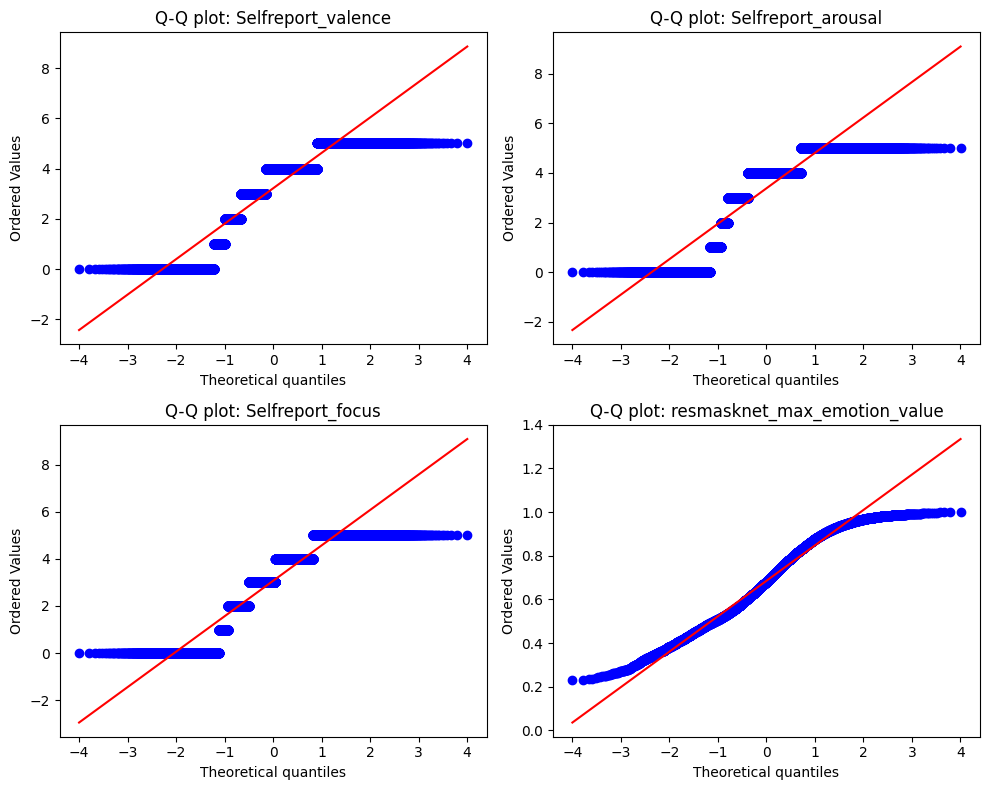

In [13]:
import scipy.stats as stats

# Variables numéricas para pruebas de normalidad
normality_vars = ["Selfreport_valence", "Selfreport_arousal", "Selfreport_focus", "resmasknet_max_emotion_value"]

missing_for_normality = [c for c in normality_vars if c not in analysis_df.columns]
if missing_for_normality:
    raise ValueError(f"Faltan columnas para pruebas de normalidad: {missing_for_normality}")

results = []
alpha = 0.05

for col in normality_vars:
    series = analysis_df[col].dropna()
    n = len(series)

    # Shapiro-Wilk: recomendado para muestras moderadas, se muestrea si n es muy grande
    shapiro_sample = series.sample(min(5000, n), random_state=42) if n > 5000 else series
    shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)

    # D'Agostino K^2: requiere al menos 8 observaciones
    if n >= 8:
        dagostino_stat, dagostino_p = stats.normaltest(series)
    else:
        dagostino_stat, dagostino_p = float("nan"), float("nan")

    # Anderson-Darling (compatibilidad entre versiones SciPy)
    try:
        anderson = stats.anderson(series, dist="norm", method="interpolate")
        ad_stat = anderson.statistic
        ad_p = anderson.pvalue
        anderson_normal = ad_p >= alpha
        crit_5 = float("nan")
    except TypeError:
        anderson = stats.anderson(series, dist="norm")
        ad_stat = anderson.statistic
        crit_5 = anderson.critical_values[2]
        anderson_normal = ad_stat < crit_5
        ad_p = float("nan")

    results.append(
        {
            "variable": col,
            "n": n,
            "shapiro_stat": shapiro_stat,
            "shapiro_p": shapiro_p,
            "shapiro_normal_0.05": shapiro_p >= alpha,
            "dagostino_stat": dagostino_stat,
            "dagostino_p": dagostino_p,
            "dagostino_normal_0.05": (dagostino_p >= alpha) if pd.notna(dagostino_p) else None,
            "anderson_stat": ad_stat,
            "anderson_p_approx": ad_p,
            "anderson_crit_5pct": crit_5,
            "anderson_normal_0.05": anderson_normal,
        }
    )

normality_df = pd.DataFrame(results)
print("Resultados de pruebas de normalidad:")
display(normality_df)

# Q-Q plots para inspección visual
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i, col in enumerate(normality_vars):
    stats.probplot(analysis_df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q plot: {col}")

plt.tight_layout()
plt.show()

Las pruebas formales rechazan normalidad en todas las variables evaluadas (p < 0.05), consistente con escalas discretas tipo Likert y con la forma no lineal de la variable de salida de FER. En los Q-Q plots, la zona central se aproxima mejor a la referencia normal, mientras que los mayores desvíos se concentran en las colas; por ello, para inferencia conviene priorizar métodos robustos o no paramétricos.

## Ajuste de distribuciones

Se comparan distribuciones candidatas para variables continuas mediante máxima verosimilitud (MLE), criterio AIC y comparación visual de densidades.

Variables tratadas como discretas (no se ajustan con distribuciones continuas):
['Selfreport_valence', 'Selfreport_arousal', 'Selfreport_focus']
Comparacion de ajustes por AIC (menor es mejor):


,variable,distribution,log_likelihood,AIC,delta_AIC,is_best
0,resmasknet_max_emotion_value,norm,8579.994459,-17155.988918,0.000000,True
1,resmasknet_max_emotion_value,gamma,8318.164579,-16630.329158,525.659759,False
2,resmasknet_max_emotion_value,lognorm,7912.961433,-15819.922865,1336.066052,False
3,resmasknet_max_emotion_value,beta,3899.598974,-7791.197949,9364.790969,False


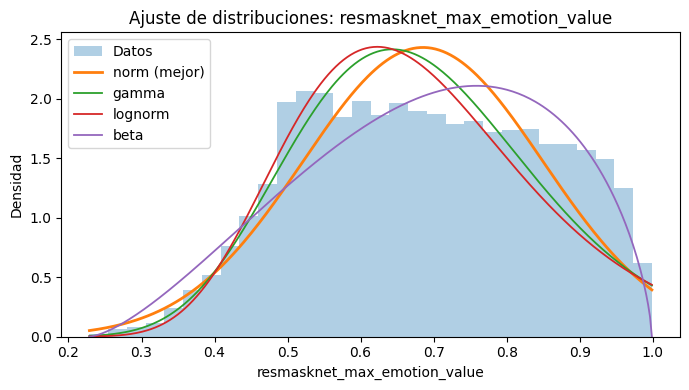

Mejor distribucion por variable continua:
- resmasknet_max_emotion_value: norm


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Ajuste de distribuciones para variables continuas
# Regla simple: si una variable tiene pocas categorias (<= 15), se trata como discreta
candidate_distributions = ["norm", "lognorm", "gamma", "beta"]
continuous_vars = [col for col in all_vars if analysis_df[col].nunique(dropna=True) > 15]
discrete_vars = [col for col in all_vars if col not in continuous_vars]

if discrete_vars:
    print("Variables tratadas como discretas (no se ajustan con distribuciones continuas):")
    print(discrete_vars)

fit_rows = []
best_fits = {}

for col in continuous_vars:
    x = analysis_df[col].dropna().astype(float).values
    if len(x) < 30:
        print(f"Se omite {col}: muestra demasiado pequena para ajuste estable.")
        continue

    col_results = []

    # Normal
    params = stats.norm.fit(x)
    ll = np.sum(stats.norm.logpdf(x, *params))
    aic = 2 * len(params) - 2 * ll
    col_results.append(("norm", params, ll, aic))

    # Lognormal (si hay no-negativos)
    if np.min(x) >= 0:
        params = stats.lognorm.fit(x, floc=0)
        ll = np.sum(stats.lognorm.logpdf(x, *params))
        aic = 2 * len(params) - 2 * ll
        col_results.append(("lognorm", params, ll, aic))

        params = stats.gamma.fit(x, floc=0)
        ll = np.sum(stats.gamma.logpdf(x, *params))
        aic = 2 * len(params) - 2 * ll
        col_results.append(("gamma", params, ll, aic))

    # Beta (escalando a (0,1))
    xmin, xmax = np.min(x), np.max(x)
    if xmax > xmin:
        eps = 1e-6
        x_beta = (x - xmin + eps) / (xmax - xmin + 2 * eps)
        beta_params = stats.beta.fit(x_beta, floc=0, fscale=1)
        ll = np.sum(stats.beta.logpdf(x_beta, *beta_params))
        aic = 2 * len(beta_params) - 2 * ll
        col_results.append(("beta", beta_params, ll, aic))

    # Guardar ranking por AIC
    col_results = sorted(col_results, key=lambda t: t[3])
    best_name, best_params, best_ll, best_aic = col_results[0]
    best_fits[col] = {"distribution": best_name, "params": best_params}

    for name, params, ll, aic in col_results:
        fit_rows.append(
            {
                "variable": col,
                "distribution": name,
                "log_likelihood": ll,
                "AIC": aic,
                "delta_AIC": aic - best_aic,
                "is_best": name == best_name,
            }
        )

fit_df = pd.DataFrame(fit_rows).sort_values(["variable", "AIC"]).reset_index(drop=True)
print("Comparacion de ajustes por AIC (menor es mejor):")
display(fit_df)

# Graficos: histograma + curvas de densidad ajustadas
for col in continuous_vars:
    x = analysis_df[col].dropna().astype(float).values
    x_grid = np.linspace(np.min(x), np.max(x), 300)

    plt.figure(figsize=(7, 4))
    plt.hist(x, bins=30, density=True, alpha=0.35, label="Datos")

    # Trazar todas las distribuciones evaluadas para la variable
    sub = fit_df[fit_df["variable"] == col]
    xmin, xmax = np.min(x), np.max(x)

    for _, row in sub.iterrows():
        dist_name = row["distribution"]

        if dist_name == "norm":
            params = stats.norm.fit(x)
            y = stats.norm.pdf(x_grid, *params)
        elif dist_name == "lognorm":
            params = stats.lognorm.fit(x, floc=0)
            y = stats.lognorm.pdf(x_grid, *params)
        elif dist_name == "gamma":
            params = stats.gamma.fit(x, floc=0)
            y = stats.gamma.pdf(x_grid, *params)
        else:  # beta
            eps = 1e-6
            x_scaled = (x_grid - xmin + eps) / (xmax - xmin + 2 * eps)
            params = stats.beta.fit((x - xmin + eps) / (xmax - xmin + 2 * eps), floc=0, fscale=1)
            y = stats.beta.pdf(x_scaled, *params) / (xmax - xmin + 2 * eps)

        label = f"{dist_name}"
        if bool(row["is_best"]):
            label += " (mejor)"
        plt.plot(x_grid, y, linewidth=2 if bool(row["is_best"]) else 1.3, label=label)

    plt.title(f"Ajuste de distribuciones: {col}")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Mejor distribucion por variable continua:")
for col, info in best_fits.items():
    print(f"- {col}: {info['distribution']}")

Para la variable continua resmasknet_max_emotion_value, el mejor ajuste relativo por AIC fue normal frente a las distribuciones candidatas probadas en esta corrida. Aun así, la inspección visual sugiere revisar en análisis futuros ajustes más flexibles si se requiere modelado fino de colas.

## Valores atípicos

Se detectan valores atípicos con criterios IQR y z-score robusto (MAD), y se revisa su concentración por sujeto y por tarea para evaluar su plausibilidad.

Resumen de valores atipicos por variable:


,variable,n,iqr_outliers_n,iqr_outliers_pct,mad_outliers_n,mad_outliers_pct,lower_iqr,upper_iqr
0,Selfreport_valence,22105,0,0.00,0,0.0,-1.000000,7.000000
1,Selfreport_arousal,22105,3818,17.27,0,0.0,1.500000,5.500000
2,Selfreport_focus,22105,0,0.00,0,0.0,-1.000000,7.000000
3,resmasknet_max_emotion_value,22105,0,0.00,0,0.0,0.148751,1.225232


Filas atipicas totales (IQR o MAD): 3818 de 22105 (17.27%)
Top 10 sujetos con mayor numero de outliers:


,outlier_count
Subject_ID,
IFE-EC-NPFC-T003-17,319
IFE-EC-NPFC-T003-28,315
IFE-EC-NPFC-T003-23,245
IFE-EC-NPFC-T003-36,235
IFE-EC-NPFC-T003-27,221
IFE-EC-NPFC-T003-26,216
IFE-EC-NPFC-T003-21,210
IFE-EC-NPFC-T003-25,204
IFE-EC-NPFC-T003-03,184


Top 10 tareas con mayor numero de outliers:


,outlier_count
Task_Num,
1.1,1315
9.1,845
8.1,453
3.1,299
4.1,215
2.1,179
3.2,89
7.2,78
8.2,75


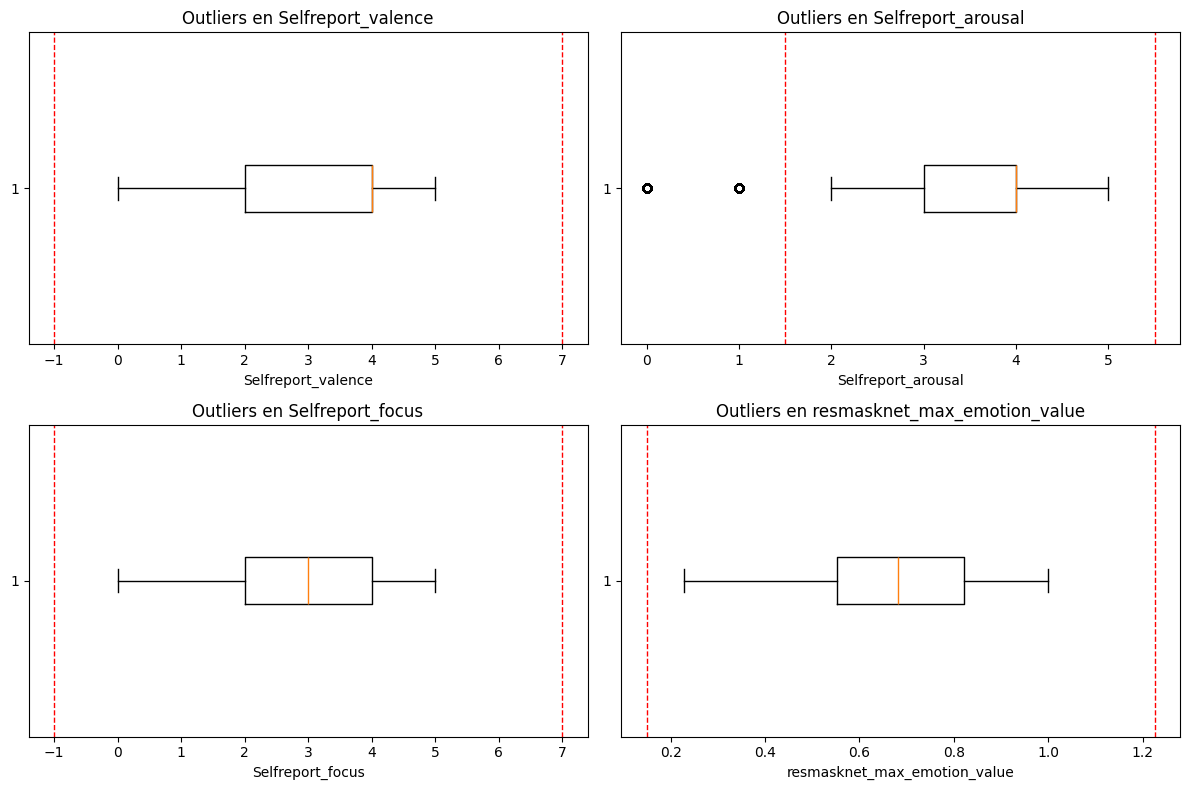

Muestra de filas atipicas (primeras 20):


,Subject_ID,Task_Num,Selfreport_valence,Selfreport_arousal,Selfreport_focus,resmasknet_max_emotion_value
0,IFE-EC-NPFC-T003-00,1.1,0,0,0,0.446330
1,IFE-EC-NPFC-T003-00,1.1,0,0,0,0.600201
2,IFE-EC-NPFC-T003-00,1.1,0,0,0,0.568611
137,IFE-EC-NPFC-T003-00,9.1,0,0,0,0.485541
138,IFE-EC-NPFC-T003-00,9.1,0,0,0,0.603971
139,IFE-EC-NPFC-T003-00,9.1,0,0,0,0.537444
140,IFE-EC-NPFC-T003-00,9.1,0,0,0,0.689036
141,IFE-EC-NPFC-T003-00,9.1,0,0,0,0.645931
142,IFE-EC-NPFC-T003-00,9.1,0,0,0,0.537390
143,IFE-EC-NPFC-T003-00,9.1,0,0,0,0.714145


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Variables numericas para deteccion de outliers
outlier_vars = ["Selfreport_valence", "Selfreport_arousal", "Selfreport_focus", "resmasknet_max_emotion_value"]
missing_outlier_cols = [c for c in outlier_vars if c not in analysis_df.columns]
if missing_outlier_cols:
    raise ValueError(f"Faltan columnas para outliers: {missing_outlier_cols}")

work_df = df.copy()

# Inicializar mascaras globales
iqr_any_mask = pd.Series(False, index=work_df.index)
mad_any_mask = pd.Series(False, index=work_df.index)

summary_rows = []

def robust_zscore_mad(series: pd.Series) -> pd.Series:
    med = series.median()
    mad = np.median(np.abs(series - med))
    if mad == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return 0.6745 * (series - med) / mad

for col in outlier_vars:
    s = work_df[col]
    valid = s.dropna()

    # IQR rule
    q1 = valid.quantile(0.25)
    q3 = valid.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_mask = (s < lower) | (s > upper)

    # Robust Z-score rule (MAD)
    rz = robust_zscore_mad(valid)
    mad_mask = pd.Series(False, index=work_df.index)
    mad_mask.loc[rz.index] = rz.abs() > 3.5

    iqr_any_mask = iqr_any_mask | iqr_mask.fillna(False)
    mad_any_mask = mad_any_mask | mad_mask.fillna(False)

    summary_rows.append(
        {
            "variable": col,
            "n": int(valid.shape[0]),
            "iqr_outliers_n": int(iqr_mask.sum()),
            "iqr_outliers_pct": round(iqr_mask.sum() / max(valid.shape[0], 1) * 100, 2),
            "mad_outliers_n": int(mad_mask.sum()),
            "mad_outliers_pct": round(mad_mask.sum() / max(valid.shape[0], 1) * 100, 2),
            "lower_iqr": lower,
            "upper_iqr": upper,
        }
    )

outlier_summary_df = pd.DataFrame(summary_rows)
print("Resumen de valores atipicos por variable:")
display(outlier_summary_df)

# Filas atipicas por criterio combinado
combined_mask = iqr_any_mask | mad_any_mask
outlier_rows = work_df.loc[combined_mask, outlier_vars].copy()
outlier_rows["outlier_iqr_any"] = iqr_any_mask.loc[outlier_rows.index].values
outlier_rows["outlier_mad_any"] = mad_any_mask.loc[outlier_rows.index].values

print(f"Filas atipicas totales (IQR o MAD): {combined_mask.sum()} de {len(work_df)} ({combined_mask.mean()*100:.2f}%)")

# Trazabilidad por sujeto y tarea (si existen columnas)
trace_cols = []
if "Subject_ID" in work_df.columns:
    trace_cols.append("Subject_ID")
if "Task_Num" in work_df.columns:
    trace_cols.append("Task_Num")

if trace_cols:
    trace_df = work_df.loc[combined_mask, trace_cols].copy()

    if "Subject_ID" in trace_cols:
        print("Top 10 sujetos con mayor numero de outliers:")
        display(trace_df["Subject_ID"].value_counts().head(10).to_frame("outlier_count"))

    if "Task_Num" in trace_cols:
        print("Top 10 tareas con mayor numero de outliers:")
        display(trace_df["Task_Num"].value_counts().head(10).to_frame("outlier_count"))

# Visualizacion: boxplots con limites IQR
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(outlier_vars):
    s = work_df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    axes[i].boxplot(s, vert=False)
    axes[i].axvline(lower, linestyle="--", linewidth=1, color="red", label="IQR lower")
    axes[i].axvline(upper, linestyle="--", linewidth=1, color="red", label="IQR upper")
    axes[i].set_title(f"Outliers en {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

# Muestra de filas atipicas para inspeccion manual
preview_cols = trace_cols + outlier_vars if trace_cols else outlier_vars
print("Muestra de filas atipicas (primeras 20):")
display(work_df.loc[combined_mask, preview_cols].head(20))

Los atípicos detectados se concentran principalmente en Selfreport_arousal y en tareas/sujetos específicos. Dado que las escalas son acotadas y ordinales, estos casos pueden reflejar estados reales de baja activación más que errores de medición; por ello, se recomienda conservarlos y complementar con análisis de sensibilidad.

# Análisis Multivariado

Esta sección examina relaciones entre variables para complementar los hallazgos univariados.

## Correlaciones

Se estiman correlaciones de Pearson y Spearman entre las variables de estudio, junto con una matriz de significancia para Spearman.

Matriz de correlación Pearson:


,Selfreport_valence,Selfreport_arousal,Selfreport_focus,resmasknet_max_emotion_value
Selfreport_valence,1.000000,0.653285,0.662435,-0.001897
Selfreport_arousal,0.653285,1.000000,0.625630,-0.028527
Selfreport_focus,0.662435,0.625630,1.000000,-0.073969
resmasknet_max_emotion_value,-0.001897,-0.028527,-0.073969,1.000000


Matriz de correlación Spearman:


,Selfreport_valence,Selfreport_arousal,Selfreport_focus,resmasknet_max_emotion_value
Selfreport_valence,1.000000,0.553647,0.583982,-0.015603
Selfreport_arousal,0.553647,1.000000,0.471460,-0.032392
Selfreport_focus,0.583982,0.471460,1.000000,-0.097644
resmasknet_max_emotion_value,-0.015603,-0.032392,-0.097644,1.000000


Matriz de p-valores (Spearman):


,Selfreport_valence,Selfreport_arousal,Selfreport_focus,resmasknet_max_emotion_value
Selfreport_valence,0.000000,0.000000,0.000000e+00,2.034886e-02
Selfreport_arousal,0.000000,0.000000,0.000000e+00,1.457125e-06
Selfreport_focus,0.000000,0.000000,0.000000e+00,5.725137e-48
resmasknet_max_emotion_value,0.020349,0.000001,5.725137e-48,0.000000e+00


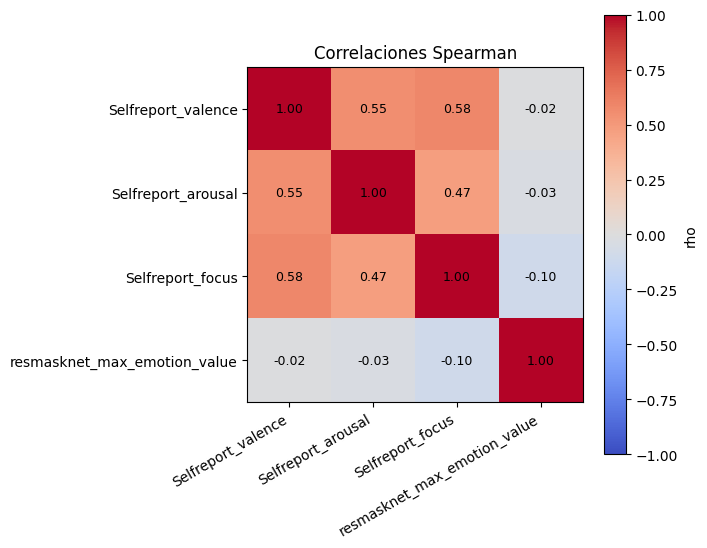

Top correlaciones por magnitud (Spearman):


,var_1,var_2,rho_spearman,abs_rho,p_value,significativo_0.05,magnitud
0,Selfreport_valence,Selfreport_focus,0.583982,0.583982,0.000000e+00,True,alta
1,Selfreport_valence,Selfreport_arousal,0.553647,0.553647,0.000000e+00,True,alta
2,Selfreport_arousal,Selfreport_focus,0.471460,0.471460,0.000000e+00,True,moderada
3,Selfreport_focus,resmasknet_max_emotion_value,-0.097644,0.097644,5.725137e-48,True,trivial
4,Selfreport_arousal,resmasknet_max_emotion_value,-0.032392,0.032392,1.457125e-06,True,trivial
5,Selfreport_valence,resmasknet_max_emotion_value,-0.015603,0.015603,2.034886e-02,True,trivial


Correlaciones con |rho| >= 0.10 y p < 0.05:


,var_1,var_2,rho_spearman,abs_rho,p_value,significativo_0.05,magnitud
0,Selfreport_valence,Selfreport_focus,0.583982,0.583982,0.0,True,alta
1,Selfreport_valence,Selfreport_arousal,0.553647,0.553647,0.0,True,alta
2,Selfreport_arousal,Selfreport_focus,0.471460,0.471460,0.0,True,moderada


,var_1,var_2,rho_spearman,p_value,magnitud
0,Selfreport_valence,Selfreport_focus,0.583982,0.0,alta
1,Selfreport_valence,Selfreport_arousal,0.553647,0.0,alta
2,Selfreport_arousal,Selfreport_focus,0.471460,0.0,moderada


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

corr_vars = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "resmasknet_max_emotion_value",
]

missing_corr_cols = [c for c in corr_vars if c not in analysis_df.columns]
if missing_corr_cols:
    raise ValueError(f"Faltan columnas para correlaciones: {missing_corr_cols}")

corr_df_base = analysis_df[corr_vars].dropna().copy()

# Correlaciones lineales (referencia) y monotónicas (principal)
pearson_corr = corr_df_base.corr(method="pearson")
spearman_corr = corr_df_base.corr(method="spearman")

# Matriz de p-valores para Spearman
rho, pvals = stats.spearmanr(corr_df_base, axis=0)
pval_matrix = pd.DataFrame(pvals, index=corr_vars, columns=corr_vars)

print("Matriz de correlación Pearson:")
display(pearson_corr)

print("Matriz de correlación Spearman:")
display(spearman_corr)

print("Matriz de p-valores (Spearman):")
display(pval_matrix)

# Heatmap anotado de Spearman
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(spearman_corr.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_vars)))
ax.set_yticks(np.arange(len(corr_vars)))
ax.set_xticklabels(corr_vars, rotation=30, ha="right")
ax.set_yticklabels(corr_vars)
ax.set_title("Correlaciones Spearman")

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        val = spearman_corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black", fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("rho")
plt.tight_layout()
plt.show()

# Ranking de correlaciones por magnitud (sin diagonal ni duplicados)
rank_df = spearman_corr.where(~np.eye(len(corr_vars), dtype=bool)).stack().reset_index()
rank_df.columns = ["var_1", "var_2", "rho_spearman"]
rank_df = rank_df[rank_df["var_1"] != rank_df["var_2"]].copy()
rank_df = rank_df.dropna(subset=["rho_spearman"])

rank_df["pair"] = rank_df.apply(lambda r: " | ".join(sorted([r["var_1"], r["var_2"]])), axis=1)
rank_df = rank_df.drop_duplicates(subset="pair").drop(columns="pair")
rank_df["abs_rho"] = rank_df["rho_spearman"].abs()
rank_df["p_value"] = rank_df.apply(lambda r: pval_matrix.loc[r["var_1"], r["var_2"]], axis=1)
rank_df["significativo_0.05"] = rank_df["p_value"] < 0.05

# Magnitud práctica aproximada
rank_df["magnitud"] = pd.cut(
    rank_df["abs_rho"],
    bins=[-0.001, 0.10, 0.30, 0.50, 1.01],
    labels=["trivial", "baja", "moderada", "alta"],
)

rank_df = rank_df.sort_values("abs_rho", ascending=False).reset_index(drop=True)

print("Top correlaciones por magnitud (Spearman):")
display(rank_df)

# Correlaciones relevantes por significancia y magnitud
relevant_corr = rank_df[(rank_df["abs_rho"] >= 0.10) & (rank_df["significativo_0.05"])].copy()
print("Correlaciones con |rho| >= 0.10 y p < 0.05:")
display(relevant_corr if not relevant_corr.empty else pd.DataFrame({"mensaje": ["No hay correlaciones que cumplan el criterio."]}))

# Tabla breve para lectura rápida
if not relevant_corr.empty:
    display(relevant_corr[["var_1", "var_2", "rho_spearman", "p_value", "magnitud"]])

### Conclusión de correlaciones

La interpretación principal debe basarse en la tabla de `relevant_corr` (`|rho| >= 0.10` y `p < 0.05`) y en la magnitud práctica (`trivial`, `baja`, `moderada`, `alta`).

Si no aparecen pares en `relevant_corr`, se interpreta que no hay asociaciones con relevancia práctica bajo este criterio, aunque puedan existir diferencias estadísticamente detectables de magnitud muy baja.

## Profundización de relaciones clave

Se profundiza en dos relaciones centrales del análisis:
- Selfreport_valence vs Selfreport_focus
- Selfreport_focus vs resmasknet_max_emotion_value

Para cada relación se reporta visualización con tendencia, coeficiente con intervalo de confianza y prueba de hipótesis.

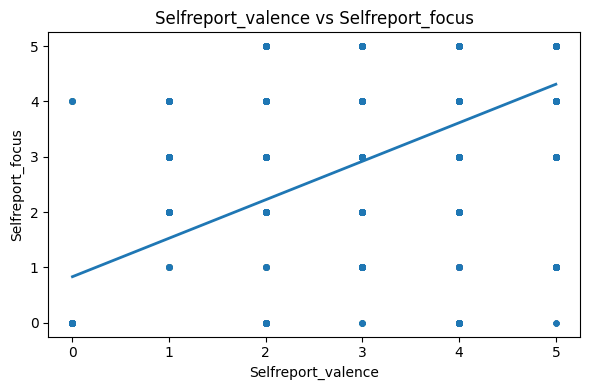

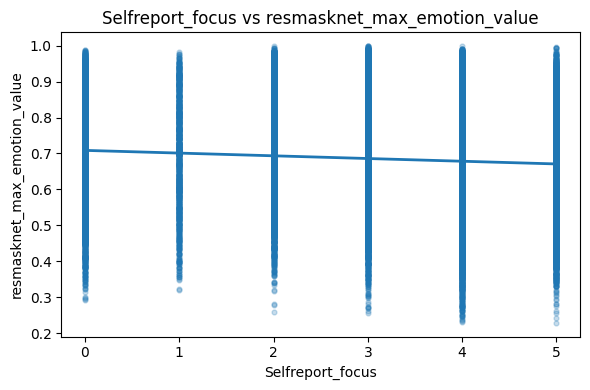

Resultados de profundización de correlaciones:


,x,y,n,pearson_r,pearson_p,spearman_rho,spearman_p,spearman_ci95_low,spearman_ci95_high,decision_alpha_0.05
0,Selfreport_valence,Selfreport_focus,22105,0.662435,0.000000e+00,0.583982,0.000000e+00,0.573878,0.593845,Rechazar H0
1,Selfreport_focus,resmasknet_max_emotion_value,22105,-0.073969,3.343705e-28,-0.097644,5.725137e-48,-0.110043,-0.085343,Rechazar H0


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Relaciones a profundizar
pairs_to_analyze = [
    ("Selfreport_valence", "Selfreport_focus"),
    ("Selfreport_focus", "resmasknet_max_emotion_value"),
]

n_boot = 2000
alpha = 0.05
rng = np.random.default_rng(42)

results_pairs = []

for x_col, y_col in pairs_to_analyze:
    pair_df = analysis_df[[x_col, y_col]].dropna().copy()
    x = pair_df[x_col].values
    y = pair_df[y_col].values
    n = len(pair_df)

    # Coeficientes
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_rho, spearman_p = stats.spearmanr(x, y)

    # IC bootstrap para Spearman
    boot_rhos = np.empty(n_boot)
    idx = np.arange(n)
    for b in range(n_boot):
        sample_idx = rng.choice(idx, size=n, replace=True)
        boot_rhos[b] = stats.spearmanr(x[sample_idx], y[sample_idx]).statistic

    ci_low, ci_high = np.percentile(boot_rhos, [2.5, 97.5])

    # Prueba formal: H0 rho = 0
    decision = "Rechazar H0" if spearman_p < alpha else "No rechazar H0"

    results_pairs.append(
        {
            "x": x_col,
            "y": y_col,
            "n": n,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p,
            "spearman_ci95_low": ci_low,
            "spearman_ci95_high": ci_high,
            "decision_alpha_0.05": decision,
        }
    )

    # Scatter + línea de tendencia lineal
    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, alpha=0.25, s=12)

    # Tendencia lineal simple
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(np.min(x), np.max(x), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, linewidth=2)

    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

pair_results_df = pd.DataFrame(results_pairs)
print("Resultados de profundización de correlaciones:")
display(pair_results_df)

Estas asociaciones no implican causalidad porque los datos son observacionales, no hay asignación aleatoria y pueden existir variables de confusión (por ejemplo, diferencias individuales, contexto de tarea o fatiga) que afecten simultáneamente a las variables analizadas.

## Comparación entre grupos

Se comparan grupos definidos por `Task_Num` para evaluar diferencias en variables de autorreporte y en `resmasknet_max_emotion_value` mediante pruebas no paramétricas y tamaño del efecto.

Tamano de grupos por Task_Num:


,n
Task_Num,
6.1,3465
4.1,2482
2.1,2441
8.1,2040
3.1,1430
1.1,1315
7.4,982
7.3,955
9.1,855


Resultados Kruskal-Wallis por variable:


,variable,n_total,k_grupos,H,p_value,epsilon_squared,significativo_0.05
0,Selfreport_valence,22105,22,10131.874929,0.000000e+00,0.457858,True
1,Selfreport_arousal,22105,22,9649.988664,0.000000e+00,0.436036,True
2,Selfreport_focus,22105,22,9892.716234,0.000000e+00,0.447028,True
3,resmasknet_max_emotion_value,22105,22,241.369456,2.207643e-39,0.009979,True


Post-hoc significativo (Mann-Whitney + Holm) para Selfreport_valence:


...

,grupo_1,grupo_2,U,p_holm,rank_biserial,abs_rbc
0,1.1,2.1,40107.5,0.0,0.975010,0.975010
77,3.1,9.1,1180729.5,0.0,-0.931427,0.931427
101,4.1,6.1,1922980.0,0.0,0.552802,0.552802
40,2.1,9.1,2044985.5,0.0,-0.959685,0.959685
110,4.1,9.1,2105746.0,0.0,-0.984578,0.984578
229,8.1,9.1,1632118.5,0.0,-0.871481,0.871481
139,5.1,9.1,659941.0,0.0,-0.986772,0.986772
31,2.1,6.1,1769637.5,0.0,0.581550,0.581550
192,6.1,8.1,5519468.5,0.0,-0.561686,0.561686
194,6.1,9.1,2926191.5,0.0,-0.975438,0.975438


Post-hoc significativo (Mann-Whitney + Holm) para Selfreport_focus:


,grupo_1,grupo_2,U,p_holm,rank_biserial,abs_rbc
0,1.1,2.1,138075.0,0.0,0.913970,0.913970
77,3.1,9.1,1208761.5,0.0,-0.977281,0.977281
40,2.1,9.1,1976530.0,0.0,-0.894085,0.894085
110,4.1,9.1,2098908.0,0.0,-0.978133,0.978133
229,8.1,9.1,1629585.5,0.0,-0.868576,0.868576
194,6.1,9.1,2912811.5,0.0,-0.966405,0.966405
61,3.1,4.1,3099232.5,0.0,-0.746411,0.746411
18,1.1,8.1,153197.5,0.0,0.885784,0.885784
17,1.1,7.5,10520.0,0.0,0.942029,0.942029
16,1.1,7.4,24985.0,0.0,0.961303,0.961303


Post-hoc significativo (Mann-Whitney + Holm) para resmasknet_max_emotion_value:


,grupo_1,grupo_2,U,p_holm,rank_biserial,abs_rbc
75,3.1,8.1,1727618.0,4.675687e-18,-0.184436,0.184436
22,2.1,3.1,1454863.0,1.138144e-15,0.166418,0.166418
192,6.1,8.1,4021515.0,2.696426e-15,-0.137853,0.137853
31,2.1,6.1,3718273.0,5.607112e-13,0.120775,0.120775
108,4.1,8.1,2865594.0,4.762651e-12,-0.131912,0.131912
222,7.4,8.1,1172543.5,6.308312e-12,-0.170624,0.170624
218,7.3,8.1,1137873.0,2.522035e-11,-0.168128,0.168128
24,2.1,4.1,2681638.0,6.981450e-10,0.114761,0.114761
36,2.1,7.4,1016509.0,7.590188e-10,0.151871,0.151871
35,2.1,7.3,990636.5,2.166568e-09,0.150090,0.150090


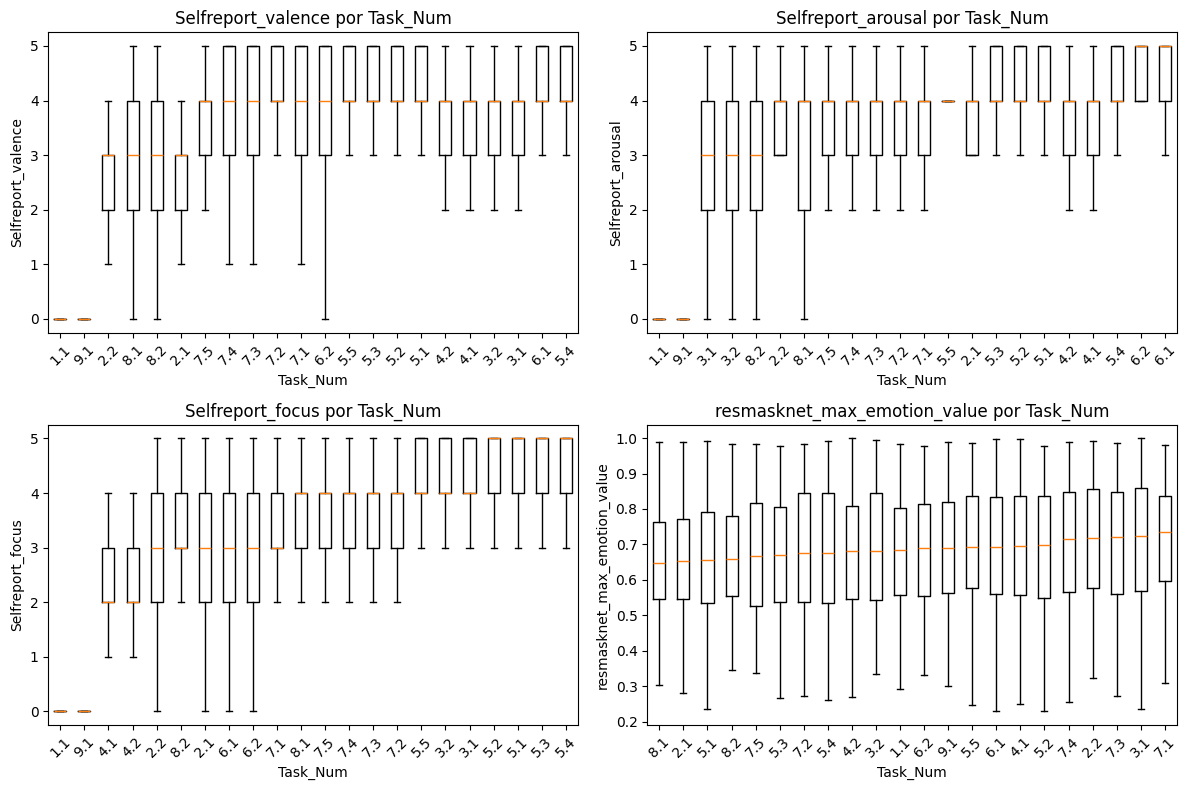

In [18]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Variables para comparar entre grupos
group_col = "Task_Num"
compare_vars = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "resmasknet_max_emotion_value",
]

required_cols = [group_col] + compare_vars
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas para comparación entre grupos: {missing_cols}")

group_df = df[required_cols].dropna().copy()

# Resumen de grupos
group_sizes = group_df[group_col].value_counts().sort_values(ascending=False)
print("Tamano de grupos por Task_Num:")
display(group_sizes.to_frame("n"))

# Kruskal-Wallis por variable
kw_rows = []
posthoc_results = {}
alpha = 0.05

for var in compare_vars:
    by_group = []
    labels = []

    for g, sub in group_df.groupby(group_col):
        vals = sub[var].dropna().values
        if len(vals) > 0:
            by_group.append(vals)
            labels.append(g)

    if len(by_group) < 2:
        continue

    h_stat, p_val = stats.kruskal(*by_group)
    n_total = sum(len(v) for v in by_group)
    k_groups = len(by_group)

    # Epsilon-squared para Kruskal-Wallis (tamaño del efecto global)
    eps_sq = (h_stat - k_groups + 1) / (n_total - k_groups) if (n_total - k_groups) > 0 else np.nan

    kw_rows.append(
        {
            "variable": var,
            "n_total": n_total,
            "k_grupos": k_groups,
            "H": h_stat,
            "p_value": p_val,
            "epsilon_squared": eps_sq,
            "significativo_0.05": p_val < alpha,
        }
    )

    # Post-hoc solo si hay diferencia global significativa
    if p_val < alpha:
        pairs = list(itertools.combinations(range(len(labels)), 2))
        pair_rows = []

        raw_p = []
        for i, j in pairs:
            g1, g2 = by_group[i], by_group[j]
            u_stat, p_pair = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            raw_p.append(p_pair)

            n1, n2 = len(g1), len(g2)
            # Rank-biserial correlation (tamaño del efecto por par)
            rbc = 1 - (2 * u_stat) / (n1 * n2)

            pair_rows.append(
                {
                    "grupo_1": labels[i],
                    "grupo_2": labels[j],
                    "U": u_stat,
                    "p_raw": p_pair,
                    "rank_biserial": rbc,
                }
            )

        # Corrección Holm-Bonferroni
        order = np.argsort(raw_p)
        m = len(raw_p)
        p_adj = np.empty(m)
        for rank, idx in enumerate(order):
            p_adj[idx] = min(1.0, raw_p[idx] * (m - rank))

        p_adj_ordered = p_adj[order]
        for t in range(1, len(p_adj_ordered)):
            p_adj_ordered[t] = max(p_adj_ordered[t], p_adj_ordered[t - 1])
        p_adj[order] = p_adj_ordered

        for r, adj in zip(pair_rows, p_adj):
            r["p_holm"] = adj
            r["significativo_0.05"] = adj < alpha
            r["abs_rbc"] = abs(r["rank_biserial"])

        ph_df = pd.DataFrame(pair_rows).sort_values("p_holm")
        ph_sig = ph_df[ph_df["significativo_0.05"]].copy()
        posthoc_results[var] = ph_sig

kw_df = pd.DataFrame(kw_rows).sort_values("p_value")
print("Resultados Kruskal-Wallis por variable:")
display(kw_df)

# Mostrar post-hoc compacto (solo significativos)
for var, ph_df in posthoc_results.items():
    print(f"Post-hoc significativo (Mann-Whitney + Holm) para {var}:")
    display(ph_df[["grupo_1", "grupo_2", "U", "p_holm", "rank_biserial", "abs_rbc"]].head(12))

# Visualización compacta por variable
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(compare_vars):
    temp = group_df[[group_col, var]].copy()

    # Ordenar grupos por mediana para legibilidad
    med_order = temp.groupby(group_col)[var].median().sort_values().index.tolist()
    values = [temp.loc[temp[group_col] == g, var].values for g in med_order]

    axes[i].boxplot(values, tick_labels=[str(g) for g in med_order], showfliers=False)
    axes[i].set_title(f"{var} por {group_col}")
    axes[i].set_xlabel(group_col)
    axes[i].set_ylabel(var)
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

En síntesis, `Task_Num` se asocia con diferencias claras en variables de autorreporte (efecto grande), mientras que en `resmasknet_max_emotion_value` la diferencia entre grupos, aunque significativa, muestra un efecto práctico pequeño.